# 網路中的網路（NiN）
:label:`sec_nin`

LeNet、AlexNet和VGG都有一個共同的设计模式：通過一系列的卷積層與彙集層來提取空間結構特徵；然後通過全連接層對特徵的表徵進行處理。
AlexNet和VGG對LeNet的改進主要在於如何擴大和加深這兩個模塊。
或者，可以想象在這個過程的早期使用全連接層。然而，如果使用了全連接層，可能會完全放棄表徵的空間結構。
*網路中的網路*（*NiN*）提供了一個非常簡單的解決方案：在每個像素的通道上分別使用多層感知機 :cite:`Lin.Chen.Yan.2013`

## (**NiN塊**)

回想一下，卷積層的輸入和輸出由四維張量組成，張量的每個軸分別對應樣本、通道、高度和寬度。
另外，全連接層的輸入和輸出通常是分別對應於樣本和特徵的二維張量。
NiN的想法是在每個像素位置（針對每個高度和寬度）應用一個全連接層。
如果我們將權重連接到每個空間位置，我們可以將其視為$1\times 1$卷積層（如 :numref:`sec_channels`中所述），或作為在每個像素位置上獨立作用的全連接層。
從另一個角度看，即將空間維度中的每個像素視為單個樣本，將通道維度視為不同特徵（feature）。

 :numref:`fig_nin`說明了VGG和NiN及它們的塊之間的主要架構差異。
NiN塊以一個普通卷積層開始，後面是兩個$1 \times 1$的卷積層。這兩個$1 \times 1$卷積層充當帶有ReLU激活函數的逐像素全連接層。
第一層的卷積窗口形狀通常由用戶設置。
隨後的卷積窗口形狀固定為$1 \times 1$。

![對比 VGG 和 NiN 及它們的區塊之間主要架構差異。](../img/nin.svg)
:width:`600px`
:label:`fig_nin`


In [1]:
import torch
from torch import nn


def nin_block(in_channels, out_channels, kernel_size, strides, padding):
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size, strides, padding),
        nn.ReLU(),
        nn.Conv2d(out_channels, out_channels, kernel_size=1), nn.ReLU(),
        nn.Conv2d(out_channels, out_channels, kernel_size=1), nn.ReLU())

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


## [**NiN模型**]

最初的NiN網路是在AlexNet後不久提出的，顯然從中得到了一些啟示。
NiN使用窗口形狀為$11\times 11$、$5\times 5$和$3\times 3$的卷積層，輸出通道數量與AlexNet中的相同。
每個NiN塊後有一個最大彙集層，彙集窗口形狀為$3\times 3$，步幅為2。

NiN和AlexNet之間的一個顯著差別是NiN完全取消了全連接層。
相反，NiN使用一個NiN塊，其輸出通道數等於標籤類別的數量。最後放一個*全局平均彙集層*（global average pooling layer），生成一個對數機率	（logits）。NiN設計的一個優點是，它顯著減少了模型所需參數的數量。然而，在實踐中，這種設計有時會增加訓練模型所需的時間。


In [2]:
net = nn.Sequential(
    nin_block(1, 96, kernel_size=11, strides=4, padding=0),
    nn.MaxPool2d(3, stride=2),
    nin_block(96, 256, kernel_size=5, strides=1, padding=2),
    nn.MaxPool2d(3, stride=2),
    nin_block(256, 384, kernel_size=3, strides=1, padding=1),
    nn.MaxPool2d(3, stride=2),
    nn.Dropout(0.5),
    # 標籤類別數是10
    nin_block(384, 10, kernel_size=3, strides=1, padding=1),
    nn.AdaptiveAvgPool2d((1, 1)),
    # 將四維的輸出轉成二維的輸出，其形狀為(批量大小,10)
    nn.Flatten())

我們創建一個數據樣本來[**查看每個塊的輸出形狀**]。


In [3]:
X = torch.rand(size=(1, 1, 224, 224))
for layer in net:
    X = layer(X)
    print(layer.__class__.__name__,'output shape:\t', X.shape)

Sequential output shape:	 torch.Size([1, 96, 54, 54])
MaxPool2d output shape:	 torch.Size([1, 96, 26, 26])
Sequential output shape:	 torch.Size([1, 256, 26, 26])
MaxPool2d output shape:	 torch.Size([1, 256, 12, 12])
Sequential output shape:	 torch.Size([1, 384, 12, 12])
MaxPool2d output shape:	 torch.Size([1, 384, 5, 5])
Dropout output shape:	 torch.Size([1, 384, 5, 5])
Sequential output shape:	 torch.Size([1, 10, 5, 5])
AdaptiveAvgPool2d output shape:	 torch.Size([1, 10, 1, 1])
Flatten output shape:	 torch.Size([1, 10])


[W NNPACK.cpp:64] Could not initialize NNPACK! Reason: Unsupported hardware.


## [**訓練模型**]

和以前一樣，我們使用Fashion-MNIST來訓練模型。訓練NiN與訓練AlexNet、VGG時相似。


Using device: mps


Epoch 1/10:   0%|          | 0/469 [00:00<?, ?it/s]

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


Epoch 1/10: 100%|██████████| 469/469 [05:21<00:00,  1.46it/s, loss=0.018, acc=9.96%] 


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


...

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


Epoch 10/10:   0%|          | 0/469 [00:00<?, ?it/s]

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


Epoch 10/10: 100%|██████████| 469/469 [07:18<00:00,  1.07it/s, loss=0.018, acc=9.99%] 


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


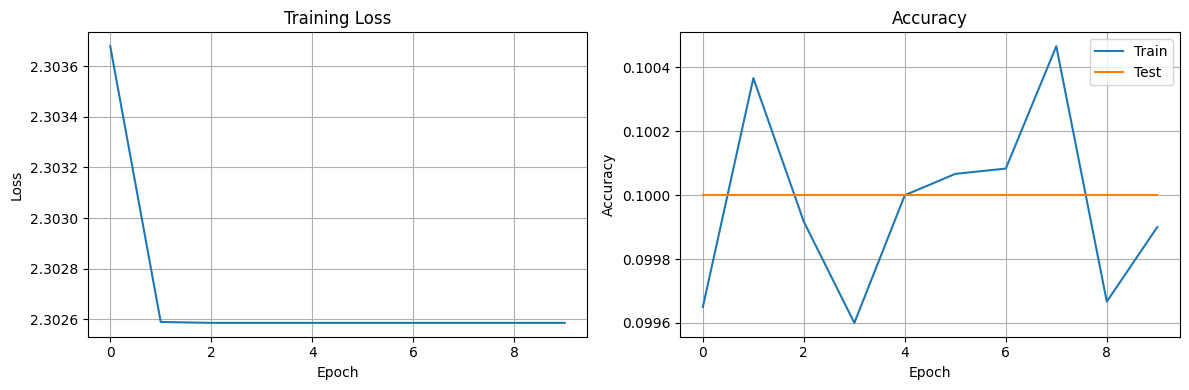


Final Results:
Final Loss: 2.3026
Final Train Accuracy: 0.0999
Final Test Accuracy: 0.1000
Average Epoch Time: 447.40s


In [4]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from tqdm import tqdm
import matplotlib.pyplot as plt
import time

def load_fashion_mnist(batch_size, resize=224):
    """加載Fashion-MNIST數據集"""
    transform = transforms.Compose([
        transforms.Resize(resize),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    
    train_dataset = datasets.FashionMNIST(
        root='./data', train=True, download=True, transform=transform
    )
    test_dataset = datasets.FashionMNIST(
        root='./data', train=False, download=True, transform=transform
    )
    
    train_loader = DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True, num_workers=2
    )
    test_loader = DataLoader(
        test_dataset, batch_size=batch_size, shuffle=False, num_workers=2
    )
    
    return train_loader, test_loader

def nin_block(in_channels, out_channels, kernel_size, stride, padding):
    """NiN塊的實現"""
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding),
        nn.ReLU(),
        nn.Conv2d(out_channels, out_channels, kernel_size=1),
        nn.ReLU(),
        nn.Conv2d(out_channels, out_channels, kernel_size=1),
        nn.ReLU()
    )

class NiN(nn.Module):
    """NiN模型"""
    def __init__(self):
        super(NiN, self).__init__()
        self.net = nn.Sequential(
            nin_block(1, 96, kernel_size=11, stride=4, padding=0),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nin_block(96, 256, kernel_size=5, stride=1, padding=2),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nin_block(256, 384, kernel_size=3, stride=1, padding=1),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Dropout(0.5),
            nin_block(384, 10, kernel_size=3, stride=1, padding=1),
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten()
        )
        
    def forward(self, x):
        return self.net(x)

def train_nin(net, train_loader, test_loader, num_epochs, lr, device):
    """訓練NiN模型"""
    net = net.to(device)
    optimizer = torch.optim.SGD(net.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    # 記錄訓練歷史
    history = {
        'train_loss': [],
        'train_acc': [],
        'test_acc': [],
        'epoch_times': []
    }
    
    for epoch in range(num_epochs):
        epoch_start = time.time()
        net.train()
        train_loss = 0
        correct_train = 0
        total_train = 0
        
        # 訓練階段
        train_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}')
        for inputs, targets in train_bar:
            inputs, targets = inputs.to(device), targets.to(device)
            
            optimizer.zero_grad()
            outputs = net(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = outputs.max(1)
            total_train += targets.size(0)
            correct_train += predicted.eq(targets).sum().item()
            
            # 更新進度條
            train_bar.set_postfix({
                'loss': f'{train_loss/total_train:.3f}',
                'acc': f'{100.*correct_train/total_train:.2f}%'
            })
        
        # 測試階段
        net.eval()
        correct_test = 0
        total_test = 0
        with torch.no_grad():
            for inputs, targets in test_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = net(inputs)
                _, predicted = outputs.max(1)
                total_test += targets.size(0)
                correct_test += predicted.eq(targets).sum().item()
        
        # 計算並記錄結果
        epoch_time = time.time() - epoch_start
        epoch_loss = train_loss / len(train_loader)
        train_acc = correct_train / total_train
        test_acc = correct_test / total_test
        
        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)
        history['epoch_times'].append(epoch_time)
        
        print(f'\nEpoch {epoch+1}/{num_epochs}:')
        print(f'Loss: {epoch_loss:.4f}')
        print(f'Train Acc: {train_acc:.4f}')
        print(f'Test Acc: {test_acc:.4f}')
        print(f'Time: {epoch_time:.2f}s')
        print('-' * 50)
    
    # 繪製訓練曲線
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'])
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train')
    plt.plot(history['test_acc'], label='Test')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    return history

if __name__ == "__main__":
    # 設置參數
    batch_size = 128
    num_epochs = 10
    lr = 0.1
    device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
    print(f"Using device: {device}")
    
    # 加載數據
    train_loader, test_loader = load_fashion_mnist(batch_size, resize=224)
    
    # 創建模型
    net = NiN()
    
    # 訓練模型
    history = train_nin(net, train_loader, test_loader, num_epochs, lr, device)
    
    # 打印最終結果
    print("\nFinal Results:")
    print(f"Final Loss: {history['train_loss'][-1]:.4f}")
    print(f"Final Train Accuracy: {history['train_acc'][-1]:.4f}")
    print(f"Final Test Accuracy: {history['test_acc'][-1]:.4f}")
    print(f"Average Epoch Time: {sum(history['epoch_times'])/len(history['epoch_times']):.2f}s")

## 小結

* NiN使用由一個卷積層和多個$1\times 1$卷積層組成的塊。該塊可以在卷積神經網路中使用，以允許更多的每像素非線性。
* NiN去除了容易造成過擬合的全連接層，將它們替換為全局平均彙集層（即在所有位置上進行求和）。該彙集層通道數量為所需的輸出數量（例如，Fashion-MNIST的輸出為10）。
* 移除全連接層可減少過擬合，同時顯著減少NiN的參數。
* NiN的設計影響了許多後續卷積神經網路設計。

## 練習

1. 調整NiN的超參數，以提高分類準確性。
1. 為什麼NiN塊中有兩個$1\times 1$卷積層？刪除其中一個，然後觀察和分析實驗現象。
1. 計算NiN的資源使用情況。
    1. 參數的數量是多少？
    1. 計算量是多少？
    1. 訓練期間需要多少顯存？
    1. 預測期間需要多少顯存？
1. 一次性直接將$384 \times 5 \times 5$的表示縮減為$10 \times 5 \times 5$的表示，會存在哪些問題？


[Discussions](https://discuss.d2l.ai/t/1869)
